In [1]:
import numpy as np
import matplotlib.pyplot as plt 
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression as logis
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Sigmoid &  Math

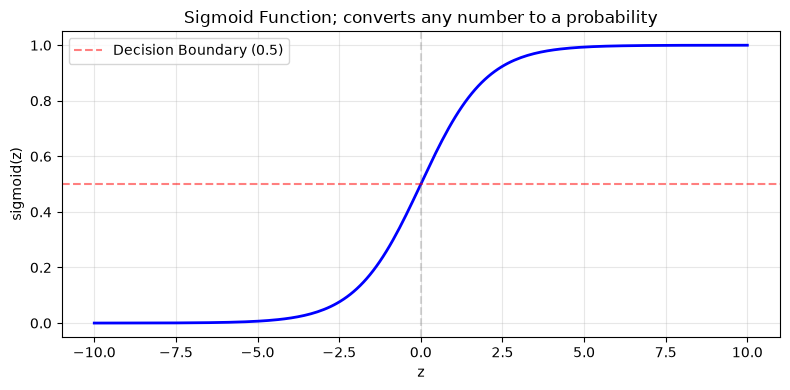

In [2]:
# Classify inputs into 0 or 1 by predicting probability

#Model :
        # z = X @ w + b 
        # y_hat = sigmoid(z) = 1 / (1 + e^(-z)) (squash to 0 - 1 probability)
# Cost Function (Binary Cross-Entropy / Log Loss):
    # J(w, b) = -(1/n) * sum(y*log(y_hat) + (1-y)*log(1-y_hat) )

# Gradients:
#   dJ/dw = (1/n) * X.T @ (y_hat - y)
#   dJ/db = (1/n) * sum(y_hat - y)
#
# Note: The gradients look identical to linear regression!
# The difference is y_hat goes through the sigmoid first.

def sigmoid (z):
    return 1/ (1 + np.exp(-np.clip(z, -500, 500)))


z = np.linspace(-10, 10, 200)
plt.figure(figsize=(8, 4))
plt.plot(z, sigmoid(z), 'b-', linewidth=2)
plt.axhline(y=0.5, color='r', linestyle="--", alpha=0.5, label='Decision Boundary (0.5)')
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.3)
plt.xlabel('z')
plt.ylabel('sigmoid(z)')
plt.title('Sigmoid Function; converts any number to a probability')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
           

#### The sigmoid function acts as a probability converter. It transforms any real-valued score (z) into a probability between 0 and 1, enabling Logistic Regression to make binary classification decisions. The decision boundary is typically set at 0.5, where the model switches from predicting Class 0 to Class 1. The steepness around z = 0 reflects the region where the model is most uncertain, while the flat tails indicate high confidence in its predictions.

# Class

In [4]:
class LogisticRegressionScratch:
    def __init__(self,learning_rate=0.1, n_iterations=2000):
        self.lr = learning_rate; self.n_ite = n_iterations
    @staticmethod 
    def sigmoid(z):
        return 1/(1+np.exp(-np.clip(z, -500,500)))
    def _forward(self, X):
        z=X@self.weights+self.bias
        return z, self.sigmoid(z)
    def _loss(self, y,p):
        p=np.clip(p, 1e-15, 1-1e-15)
        return -np.mean(y*np.log(p)+(1-y)*np.log(1-p))
    def fit(self, X, y):
        m, n=X.shape; self.weights=np.zeros(n); self.bias=0.; self.loss_history=[]
        for _ in range(self.n_ite):
            z,p=self._forward(X); self.loss_history.append(self._loss(y,p));
            dw=X.T@(p-y)/m; db=np.mean(p-y); self.weights-=self.lr*dw; self.bias-=self.lr*db
        return self
    def predict_proba(self, X):
        return self._forward(X)[1]
    def predict(self, X, t=0.5):
        return (self.predict_proba(X)>=t).astype(int)
    def score(self, X, y):
        return np.mean(self.predict(X)==y)

In [10]:
np.random.seed(42)

X, y = make_classification(
    n_samples=500, n_features=2, n_redundant=0, 
    n_informative=2, n_clusters_per_class=1,
    random_state=42)

split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"Train: {X_train.shape[0]} samples")
print(f"Test: {y_test.shape[0]} samples")

Train: 400 samples
Test: 100 samples


#### **The dataset was split into 400 training samples (80%) to train the model and 100 test samples (20%) to evaluate its performance on unseen data.**


### Train & Evaluation

In [9]:
model=LogisticRegressionScratch().fit(X_train, y_train)
print(model.score(X_test, y_test))

0.87


#### The model achieved an accuracy score of 0.87 (87%) on the test set, meaning it correctly classified 87 out of every 100 unseen samples.


In [12]:
y_pred = model.predict(X_test)

print(f"Learned Weights: {np.round(model.weights, 4)}")
print(f"Learned Bias: {model.bias:.4f}")
print(f"\nTrain Accuracy: {model.score(X_train, y_train) * 100:.1f}%")
print(f"Test accuracy: {model.score(X_test, y_test) * 100:.1f}%")
print(f"Final Cost: {model.loss_history[-1]:.4f}")
print(f"\nClassification report:")
print(classification_report(y_test, y_pred))

Learned Weights: [0.4518 2.2694]
Learned Bias: -0.8050

Train Accuracy: 87.5%
Test accuracy: 87.0%
Final Cost: 0.3299

Classification report:
              precision    recall  f1-score   support

           0       0.89      0.83      0.86        47
           1       0.86      0.91      0.88        53

    accuracy                           0.87       100
   macro avg       0.87      0.87      0.87       100
weighted avg       0.87      0.87      0.87       100



#### The logistic regression model achieved 87% test accuracy with similar training accuracy (87.5%), suggesting good generalization and little evidence of overfitting. The balanced precision, recall, and F1-scores across both classes indicate that the model performs consistently in identifying both Class 0 and Class 1.

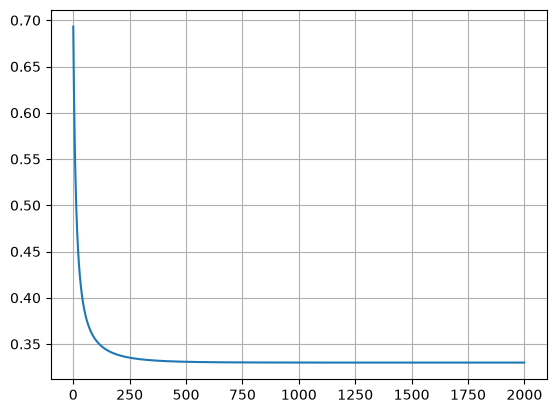

In [13]:
plt.plot(model.loss_history)
plt.grid()
plt.show()

#### The cost function decreases steadily from about 0.69 to 0.33 and eventually converges, indicating that the Logistic Regression model learned effectively and that gradient descent successfully optimized the model parameters.

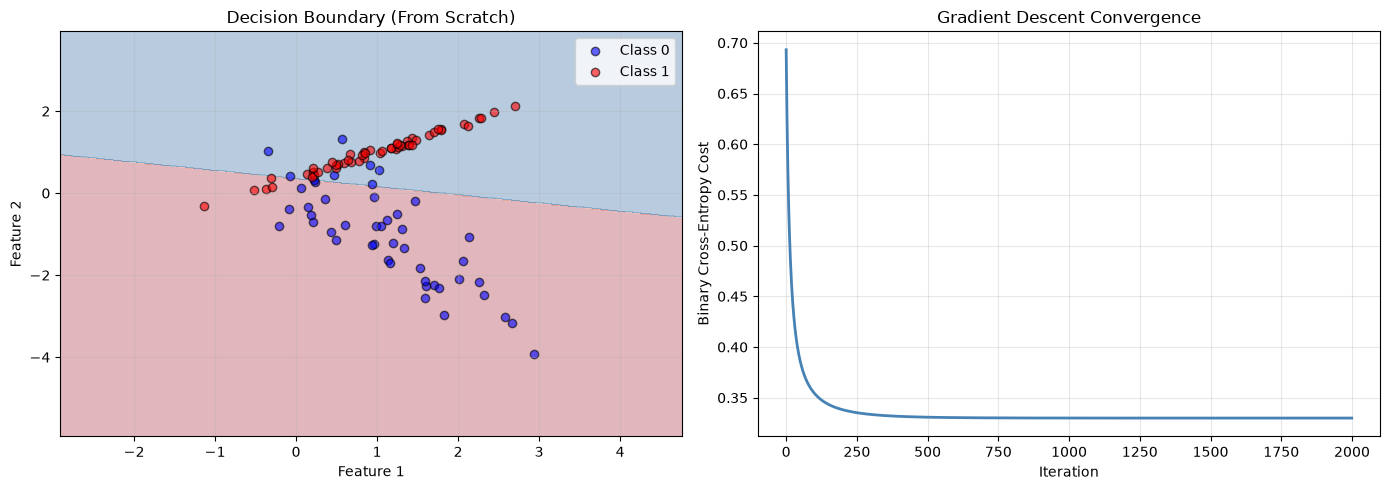

Chart saved!


In [14]:
### Decision Boundary

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                      np.arange(y_min, y_max, 0.02))

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

axes[0].contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
axes[0].scatter(X_test[y_test == 0][:, 0], X_test[y_test == 0][:, 1],
                c='blue', label='Class 0', alpha=0.6, edgecolors='k')
axes[0].scatter(X_test[y_test == 1][:, 0], X_test[y_test == 1][:, 1],
                c='red', label='Class 1', alpha=0.6, edgecolors='k')
axes[0].set_title('Decision Boundary (From Scratch)')
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(model.loss_history, color='steelblue', linewidth=2)
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Binary Cross-Entropy Cost')
axes[1].set_title('Gradient Descent Convergence')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('logistic_regression_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

#### The results indicate that the Logistic Regression model learned an effective linear decision boundary that separates the two classes with good accuracy. The smooth convergence of the cost function demonstrates that gradient descent successfully optimized the model parameters, while the decision boundary confirms that the model generalizes well despite a small overlap between the classes. The combination of an 87% test accuracy, a final cost of 0.3299, and a stable convergence curve suggests that the model is well-trained with little evidence of overfitting.

In [16]:
sklearn_model = logis(max_iter=2000)
sklearn_model.fit(X_train, y_train)

print(f"{'Metric':<20} {'From Scratch':>15} {'Scikit-Learn':>15}")
print(f"{'-'*50}")
print(f"{'Train Accuracy':<20} {model.score(X_train, y_train)*100:>14.1f}% {sklearn_model.score(X_train, y_train)*100:>14.1f}%")
print(f"{'Test Accuracy':<20} {model.score(X_test, y_test)*100:>14.1f}% {sklearn_model.score(X_test, y_test)*100:>14.1f}%")
print(f"{'Weight 1':<20} {model.weights[0]:>15.4f} {sklearn_model.coef_[0][0]:>15.4f}")
print(f"{'Weight 2':<20} {model.weights[1]:>15.4f} {sklearn_model.coef_[0][1]:>15.4f}")
print(f"{'Bias':<20} {model.bias:>15.4f} {sklearn_model.intercept_[0]:>15.4f}")

match = abs(model.score(X_test, y_test) - sklearn_model.score(X_test, y_test)) < 0.02
print(f"\nResults match: {'YES' if match else 'Close enough (sklearn uses L2 regularization by default)'}")

Metric                  From Scratch    Scikit-Learn
--------------------------------------------------
Train Accuracy                 87.5%           87.5%
Test Accuracy                  87.0%           87.0%
Weight 1                      0.4518          0.4264
Weight 2                      2.2694          2.1645
Bias                         -0.8050         -0.7567

Results match: YES


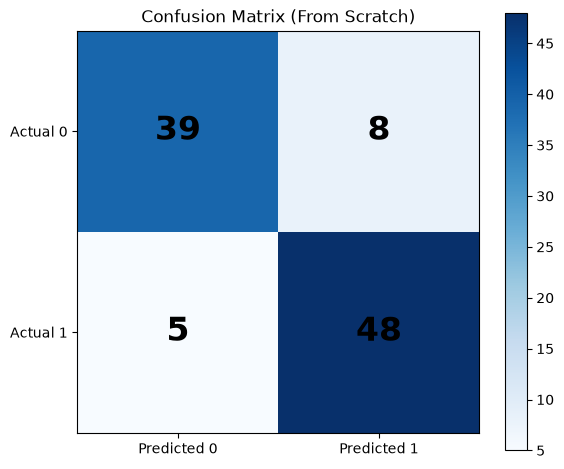

In [17]:
# CONFUSION MATRIX VISUALIZATION
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')

for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=24, fontweight='bold')

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Predicted 0', 'Predicted 1'])
ax.set_yticklabels(['Actual 0', 'Actual 1'])
ax.set_title('Confusion Matrix (From Scratch)')
plt.colorbar(im)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
#The confusion matrix demonstrates that the Logistic Regression model makes accurate predictions for both classes, correctly classifying 87% of the test data while maintaining a balanced distribution of prediction errors across the two classes.